# IMS Anomaly Validation

This notebook validates whether anomaly alerts correspond to degradation evidence before platform integration.

It uses the local IMS documentation for known failed bearings and sensor-channel mappings. It does not infer undocumented mappings.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.ims_anomaly_validation import (
    IMS_DOCUMENTATION,
    add_full_life_fraction,
    add_method_flags,
    add_proxy_labels,
    aggregate_channel_scores,
    calculate_validation_metrics,
    explain_overlap,
    save_json,
    save_selected_artifacts,
    select_method,
    validate_documented_mapping,
)

FEATURE_PATH = PROJECT_ROOT / "data" / "processed" / "ims_features.csv"
SCORE_PATH = PROJECT_ROOT / "data" / "processed" / "ims_anomaly_baseline_scores.csv"
VALIDATED_SCORE_PATH = PROJECT_ROOT / "data" / "processed" / "ims_validated_anomaly_scores.csv"
METRICS_PATH = PROJECT_ROOT / "artifacts" / "metrics" / "ims_anomaly_validation.json"
SOURCE_IF_MODEL_PATH = PROJECT_ROOT / "artifacts" / "models" / "ims_isolation_forest_baseline.joblib"
PLOTS_DIR = PROJECT_ROOT / "artifacts" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

PROXY_WINDOWS = [0.05, 0.10, 0.15, 0.20]
sns.set_theme(style="whitegrid")

FEATURE_PATH, SCORE_PATH

(WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/data/processed/ims_features.csv'),
 WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/data/processed/ims_anomaly_baseline_scores.csv'))

## 1. Documented IMS Mappings

In [2]:
documentation_table = pd.DataFrame(
    {
        "experiment": documented.experiment,
        "failed_bearings": ", ".join(str(item) for item in documented.failed_bearings),
        "channel_to_bearing": documented.channel_to_bearing,
        "channel_to_axis": documented.channel_to_axis,
        "source": documented.source,
    }
    for documented in IMS_DOCUMENTATION.values()
)
documentation_table

,experiment,failed_bearings,channel_to_bearing,channel_to_axis,source
0,1st_test,"3, 4","{1: 1, 2: 1, 3: 2, 4: 2, 5: 3, 6: 3, 7: 4, 8: 4}","{1: 'x', 2: 'y', 3: 'x', 4: 'y', 5: 'x', 6: 'y...",IMS Bearing Data readme: data set 1 has two ac...
1,2nd_test,1,"{1: 1, 2: 2, 3: 3, 4: 4}","{1: None, 2: None, 3: None, 4: None}",IMS Bearing Data readme: data set 2 has one ac...
2,3rd_test,3,"{1: 1, 2: 2, 3: 3, 4: 4}","{1: None, 2: None, 3: None, 4: None}",IMS Bearing Data readme: data set 3 has one ac...


## 2. Load Current Feature and Score Tables

In [3]:
features = pd.read_csv(FEATURE_PATH, parse_dates=["timestamp"])
scores = pd.read_csv(SCORE_PATH, parse_dates=["timestamp"])

features = features.sort_values(["experiment", "timestamp", "sensor_channel"]).reset_index(drop=True)
scores = scores.sort_values(["experiment", "timestamp", "sensor_channel"]).reset_index(drop=True)

features_with_life = add_full_life_fraction(features)
mapping_validation = validate_documented_mapping(features)

input_inventory = pd.DataFrame(
    [
        {
            "feature_rows": len(features),
            "feature_experiments": features["experiment"].nunique(),
            "score_rows": len(scores),
            "score_experiments": scores["experiment"].nunique(),
            "score_experiment_names": ", ".join(sorted(scores["experiment"].unique())),
            "mapping_rows_checked": len(mapping_validation),
            "mapping_failures": int((~mapping_validation["bearing_mapping_ok"] | ~mapping_validation["axis_mapping_ok"]).sum()),
        }
    ]
)

input_inventory

,feature_rows,feature_experiments,score_rows,score_experiments,score_experiment_names,mapping_rows_checked,mapping_failures
0,46480,3,8624,1,1st_test,16,0


In [4]:
mapping_validation

,experiment,sensor_channel,expected_bearing,observed_bearings,bearing_mapping_ok,expected_axis,axis_mapping_ok,source
0,1st_test,1,1,[1],True,x,True,IMS Bearing Data readme: data set 1 has two ac...
1,1st_test,2,1,[1],True,y,True,IMS Bearing Data readme: data set 1 has two ac...
2,1st_test,3,2,[2],True,x,True,IMS Bearing Data readme: data set 1 has two ac...
3,1st_test,4,2,[2],True,y,True,IMS Bearing Data readme: data set 1 has two ac...
4,1st_test,5,3,[3],True,x,True,IMS Bearing Data readme: data set 1 has two ac...
5,1st_test,6,3,[3],True,y,True,IMS Bearing Data readme: data set 1 has two ac...
6,1st_test,7,4,[4],True,x,True,IMS Bearing Data readme: data set 1 has two ac...
7,1st_test,8,4,[4],True,y,True,IMS Bearing Data readme: data set 1 has two ac...
8,2nd_test,1,1,[1],True,NaN,True,IMS Bearing Data readme: data set 2 has one ac...
9,2nd_test,2,2,[2],True,NaN,True,IMS Bearing Data readme: data set 2 has one ac...


## 3. Aggregate Channel Alerts by Experiment, Timestamp, and Bearing

In [5]:
scores_with_life = scores.drop(columns=["full_life_fraction"], errors="ignore").merge(
    features_with_life[["experiment", "timestamp", "sensor_channel", "bearing", "full_life_fraction"]],
    on=["experiment", "timestamp", "sensor_channel", "bearing"],
    how="left",
)
bearing_scores = aggregate_channel_scores(scores_with_life)
bearing_scores = add_method_flags(bearing_scores)

aggregation_summary = bearing_scores.groupby("experiment").agg(
    rows=("timestamp", "size"),
    timestamps=("timestamp", "nunique"),
    bearings=("bearing", "nunique"),
    raw_z_alerts=("z_is_anomaly", "sum"),
    raw_if_alerts=("if_is_anomaly", "sum"),
    persistent_z_alerts=("z_persistent_alert", "sum"),
    persistent_if_alerts=("if_persistent_alert", "sum"),
).reset_index()

aggregation_summary

,experiment,rows,timestamps,bearings,raw_z_alerts,raw_if_alerts,persistent_z_alerts,persistent_if_alerts
0,1st_test,4312,1078,4,38,45,0,13


## 4. Proxy Degradation Windows and Metrics

In [6]:
validation_metrics = calculate_validation_metrics(bearing_scores, PROXY_WINDOWS)
validation_metrics

,method,proxy_window,precision,recall,f1,pr_auc,false_alerts_per_day,alert_lead_time_days,episodes,false_episodes,alerts,failing_bearing_alerts,failing_bearing_concentration
0,z_score,0.05,0.000000,0.000000,0.000000,0.085084,0.000000,NaN,0,0,0,0,0.0
1,isolation_forest,0.05,0.461538,0.027778,0.052402,0.161353,0.391273,2.884028,6,4,13,13,1.0
2,or,0.05,0.625000,0.023148,0.044643,0.159332,0.097818,1.700370,2,1,8,8,1.0
3,and,0.05,0.000000,0.000000,0.000000,0.117805,0.000000,NaN,0,0,0,0,0.0
4,weighted,0.05,0.220339,0.060185,0.094545,0.171558,0.880365,4.926615,12,9,59,59,1.0
5,z_score,0.10,0.000000,0.000000,0.000000,0.132000,0.000000,NaN,0,0,0,0,0.0
6,isolation_forest,0.10,0.846154,0.025463,0.049438,0.339848,0.097818,2.884028,6,1,13,13,1.0
7,or,0.10,1.000000,0.018519,0.036364,0.333914,0.000000,1.700370,2,0,8,8,1.0
8,and,0.10,0.000000,0.000000,0.000000,0.178588,0.000000,NaN,0,0,0,0,0.0
9,weighted,0.10,0.220339,0.030093,0.052953,0.303932,0.880365,4.926615,12,9,59,59,1.0


In [7]:
selected_payload = select_method(validation_metrics)
method_ranking = pd.DataFrame(selected_payload["method_ranking"])
method_ranking

,method,mean_f1,mean_precision,mean_recall,mean_pr_auc,mean_false_alerts_per_day,mean_failing_bearing_concentration,mean_alert_lead_time_days
0,weighted,0.073891,0.368644,0.042535,0.381365,0.709183,1.0,4.926615
1,isolation_forest,0.042705,0.826923,0.022087,0.445107,0.122273,1.0,2.884028
2,or,0.030936,0.906250,0.015818,0.435848,0.024455,1.0,1.700370
3,and,0.000000,0.000000,0.000000,0.212750,0.000000,0.0,NaN
4,z_score,0.000000,0.000000,0.000000,0.157705,0.000000,0.0,NaN


## 5. Why the Original Alerts Barely Overlap

In [8]:
channel_level_overlap = {
    "channel_raw_z_alerts": int(scores["z_is_anomaly"].astype(bool).sum()),
    "channel_raw_if_alerts": int(scores["if_is_anomaly"].astype(bool).sum()),
    "channel_raw_overlap": int((scores["z_is_anomaly"].astype(bool) & scores["if_is_anomaly"].astype(bool)).sum()),
}
overlap_diagnostics = {**channel_level_overlap, **explain_overlap(bearing_scores)}
overlap_by_bearing = bearing_scores.groupby("bearing").agg(
    raw_z_alerts=("z_is_anomaly", "sum"),
    raw_if_alerts=("if_is_anomaly", "sum"),
    raw_overlap=("z_is_anomaly", lambda values: int((values.astype(bool) & bearing_scores.loc[values.index, "if_is_anomaly"].astype(bool)).sum())),
    persistent_z_alerts=("z_persistent_alert", "sum"),
    persistent_if_alerts=("if_persistent_alert", "sum"),
    persistent_overlap=("z_persistent_alert", lambda values: int((values.astype(bool) & bearing_scores.loc[values.index, "if_persistent_alert"].astype(bool)).sum())),
).reset_index()

pd.DataFrame([overlap_diagnostics]), overlap_by_bearing

(   channel_raw_z_alerts  channel_raw_if_alerts  channel_raw_overlap  \
 0                    44                     45                    3   
 
    raw_z_alerts  raw_if_alerts  raw_overlap  persistent_z_alerts  \
 0            38             45            5                    0   
 
    persistent_if_alerts  persistent_overlap  z_only_persistent  \
 0                    13                   0                  0   
 
    if_only_persistent                                             reason  
 0                  13  Z-score compares each bearing to recent rollin...  ,
    bearing  raw_z_alerts  raw_if_alerts  raw_overlap  persistent_z_alerts  \
 0        1             3              0            0                    0   
 1        2             2              0            0                    0   
 2        3            13             45            5                    0   
 3        4            20              0            0                    0   
 
    persistent_if_alerts  persist

## 6. Validation Plots

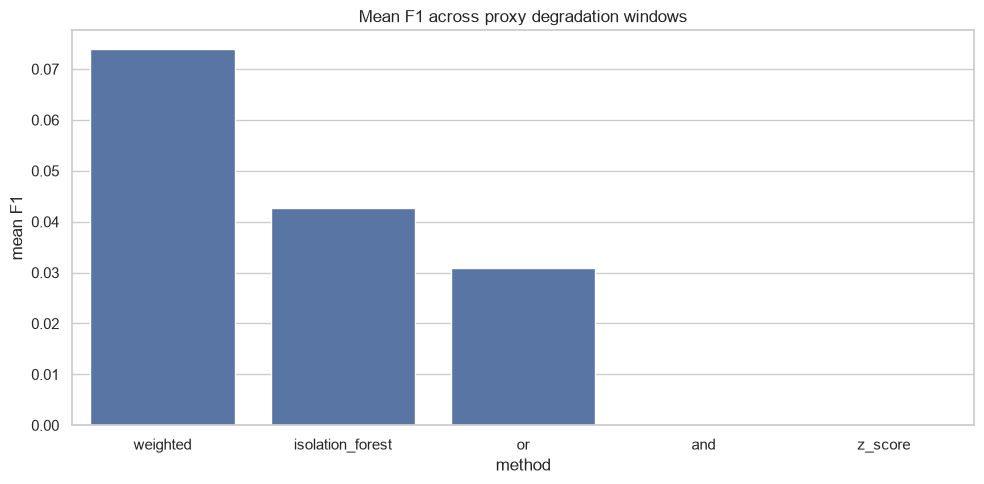

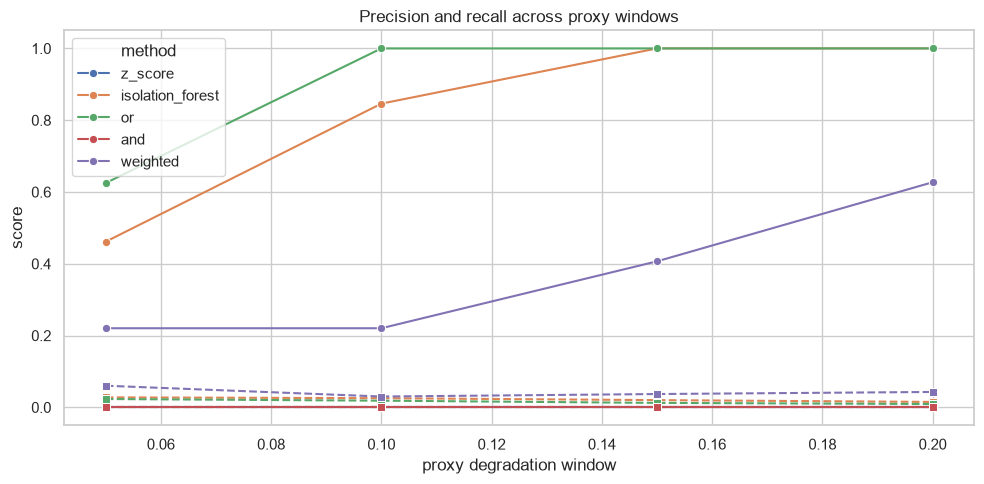

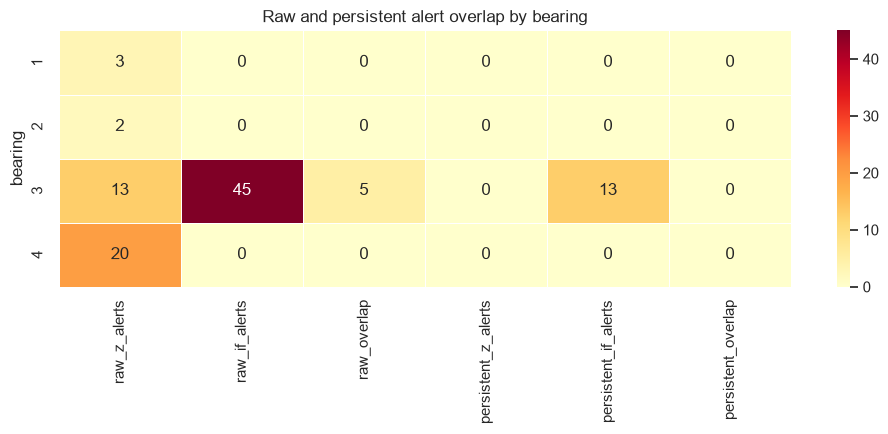

[WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/artifacts/plots/ims_validation_method_f1.png'),
 WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/artifacts/plots/ims_validation_precision_recall_windows.png'),
 WindowsPath('C:/Users/Balsem/Desktop/GMAO/ai-service/artifacts/plots/ims_validation_overlap_by_bearing.png')]

In [9]:
plot_paths = []

figure, axis = plt.subplots(figsize=(10, 5))
sns.barplot(data=method_ranking, x="method", y="mean_f1", ax=axis)
axis.set_title("Mean F1 across proxy degradation windows")
axis.set_xlabel("method")
axis.set_ylabel("mean F1")
figure.tight_layout()
path = PLOTS_DIR / "ims_validation_method_f1.png"
figure.savefig(path, dpi=160, bbox_inches="tight")
plot_paths.append(path)
plt.show()

figure, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=validation_metrics, x="proxy_window", y="precision", hue="method", marker="o", ax=axis)
sns.lineplot(data=validation_metrics, x="proxy_window", y="recall", hue="method", marker="s", linestyle="--", ax=axis, legend=False)
axis.set_title("Precision and recall across proxy windows")
axis.set_xlabel("proxy degradation window")
axis.set_ylabel("score")
figure.tight_layout()
path = PLOTS_DIR / "ims_validation_precision_recall_windows.png"
figure.savefig(path, dpi=160, bbox_inches="tight")
plot_paths.append(path)
plt.show()

heatmap_data = overlap_by_bearing.set_index("bearing")[["raw_z_alerts", "raw_if_alerts", "raw_overlap", "persistent_z_alerts", "persistent_if_alerts", "persistent_overlap"]]
figure, axis = plt.subplots(figsize=(10, 4.5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=axis)
axis.set_title("Raw and persistent alert overlap by bearing")
figure.tight_layout()
path = PLOTS_DIR / "ims_validation_overlap_by_bearing.png"
figure.savefig(path, dpi=160, bbox_inches="tight")
plot_paths.append(path)
plt.show()

plot_paths

## 7. Save Validated Scores, Metrics, and Selected Model Metadata

In [10]:
selected_artifacts = save_selected_artifacts(
    PROJECT_ROOT,
    selected_payload,
    SOURCE_IF_MODEL_PATH,
    features_with_life=features_with_life,
    channel_scores=scores,
    bearing_scores=bearing_scores,
)
bearing_scores.to_csv(VALIDATED_SCORE_PATH, index=False)

payload = {
    "inputs": {
        "features": FEATURE_PATH.as_posix(),
        "baseline_scores": SCORE_PATH.as_posix(),
    },
    "outputs": {
        "validated_scores": VALIDATED_SCORE_PATH.as_posix(),
        "metrics_json": METRICS_PATH.as_posix(),
        "plots": [path.as_posix() for path in plot_paths],
        "selected_metadata": selected_artifacts["metadata_path"].as_posix(),
        "selected_model": selected_artifacts["model_path"].as_posix() if selected_artifacts["model_path"] else None,
    },
    "documentation": {key: documented.source for key, documented in IMS_DOCUMENTATION.items()},
    "mapping_validation": mapping_validation.to_dict(orient="records"),
    "aggregation_summary": aggregation_summary.to_dict(orient="records"),
    "proxy_windows": PROXY_WINDOWS,
    "validation_metrics": validation_metrics.to_dict(orient="records"),
    "method_ranking": selected_payload["method_ranking"],
    "selected_method": selected_payload["selected"],
    "overlap_diagnostics": overlap_diagnostics,
    "limitations": [
        "Proxy labels use late-life windows because per-file ground-truth degradation labels are not provided.",
        "The available baseline score file covers only the later chronological portion of 1st_test.",
        "The 3rd_test file count remains higher than the IMS readme expectation and is not used by this baseline validation.",
        "No FastAPI or platform integration is included in this step.",
    ],
}

save_json(METRICS_PATH, payload)

saved_outputs = pd.DataFrame(
    [
        {"artifact": "validated anomaly scores", "path": VALIDATED_SCORE_PATH.as_posix(), "rows": len(bearing_scores)},
        {"artifact": "validation metrics JSON", "path": METRICS_PATH.as_posix(), "rows": None},
        {"artifact": "selected model metadata", "path": selected_artifacts["metadata_path"].as_posix(), "rows": None},
        {"artifact": "selected model artifact", "path": selected_artifacts["model_path"].as_posix() if selected_artifacts["model_path"] else None, "rows": None},
        *({"artifact": path.stem, "path": path.as_posix(), "rows": None} for path in plot_paths),
    ]
)

saved_outputs

,artifact,path,rows
0,validated anomaly scores,C:/Users/Balsem/Desktop/GMAO/ai-service/data/p...,4312.0
1,validation metrics JSON,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
2,selected model metadata,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
3,selected model artifact,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
4,ims_validation_method_f1,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
5,ims_validation_precision_recall_windows,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
6,ims_validation_overlap_by_bearing,C:/Users/Balsem/Desktop/GMAO/ai-service/artifa...,NaN
